In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("Telco Customer Churn.csv")

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.shape

(7043, 21)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
from sklearn.preprocessing import LabelEncoder


In [10]:
df.drop('customerID', axis=1, inplace=True)

In [11]:

binary_cols = [
    'gender',
    'Partner',
    'Dependents',
    'PhoneService',
    'PaperlessBilling',
    'Churn'
]

le = LabelEncoder()

for col in binary_cols:
    df[col] = le.fit_transform(df[col])

In [12]:
multi_cols = [
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaymentMethod'
]

df = pd.get_dummies(df, columns=multi_cols, dtype=int)

In [13]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,1,0,0,1,0,0,0,0,1,0
1,1,0,0,0,34,1,0,56.95,1889.5,0,...,1,0,0,0,1,0,0,0,0,1
2,1,0,0,0,2,1,1,53.85,108.15,1,...,1,0,0,1,0,0,0,0,0,1
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,1,0,0,0,1,0,1,0,0,0
4,0,0,0,0,2,1,1,70.70,151.65,1,...,1,0,0,1,0,0,0,0,1,0


In [14]:
#Create tenure groups

In [15]:
df['tenure_group'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 24, 48, 72],
    labels=['0-1yr', '1-2yr', '2-4yr', '4-6yr']
)

In [16]:
df.dtypes

gender                                        int64
SeniorCitizen                                 int64
Partner                                       int64
Dependents                                    int64
tenure                                        int64
PhoneService                                  int64
PaperlessBilling                              int64
MonthlyCharges                              float64
TotalCharges                                 object
Churn                                         int64
MultipleLines_No                              int64
MultipleLines_No phone service                int64
MultipleLines_Yes                             int64
InternetService_DSL                           int64
InternetService_Fiber optic                   int64
InternetService_No                            int64
OnlineSecurity_No                             int64
OnlineSecurity_No internet service            int64
OnlineSecurity_Yes                            int64
OnlineBackup

In [17]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [18]:
df["TotalCharges"].isnull().sum()

np.int64(11)

In [19]:
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

In [20]:
df['AvgChargePerMonth'] = df['TotalCharges'] / (df['tenure'] + 1)

In [21]:
#Monthly charge categories
df['MonthlyChargeGroup'] = pd.cut(
    df['MonthlyCharges'],
    bins=[0, 35, 70, 120],
    labels=['Low', 'Medium', 'High']
)

In [22]:
#Senior citizen + dependent interaction
df['SeniorNoDependents'] = (
    (df['SeniorCitizen'] == 1) &
    (df['Dependents'] == 0)
).astype(int)

In [23]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group,AvgChargePerMonth,MonthlyChargeGroup,SeniorNoDependents
0,0,0,1,0,1,0,1,29.85,29.85,0,...,0,0,0,0,1,0,0-1yr,14.925000,Low,0
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,1,0,0,0,0,1,2-4yr,53.985714,Medium,0
2,1,0,0,0,2,1,1,53.85,108.15,1,...,0,0,0,0,0,1,0-1yr,36.050000,Medium,0
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,1,0,1,0,0,0,2-4yr,40.016304,Medium,0
4,0,0,0,0,2,1,1,70.70,151.65,1,...,0,0,0,0,1,0,0-1yr,50.550000,High,0


In [24]:
df = pd.get_dummies(
    df,
    columns=['tenure_group', 'MonthlyChargeGroup'],
    drop_first=True
)

In [25]:
num_cols = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges',
    'AvgChargePerMonth'
]

In [26]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [28]:
bool_cols = X_train.select_dtypes(include='bool').columns

X_train[bool_cols] = X_train[bool_cols].astype(int)
X_test[bool_cols] = X_test[bool_cols].astype(int)

In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [30]:
X_train.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,MultipleLines_No,...,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,AvgChargePerMonth,SeniorNoDependents,tenure_group_1-2yr,tenure_group_2-4yr,tenure_group_4-6yr,MonthlyChargeGroup_Medium,MonthlyChargeGroup_High
3738,1,0,0,0,0.102371,0,0,-0.521976,-0.263289,0,...,0,1,0,-0.236288,0,0,1,0,1,0
3151,1,0,1,1,-0.711743,1,0,0.337478,-0.504814,1,...,0,0,1,0.182960,0,1,0,0,0,1
4860,1,0,1,1,-0.793155,0,0,-0.809013,-0.751213,0,...,0,0,1,-0.322843,0,1,0,0,1,0
3867,0,0,1,0,-0.263980,1,1,0.284384,-0.173699,1,...,1,0,0,0.159364,0,0,1,0,0,1
3810,1,0,1,1,-1.281624,1,0,-0.676279,-0.990851,1,...,0,1,0,-0.660445,0,0,0,0,1,0


In [31]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [32]:
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

In [33]:
importance_df.head(15)

,Feature,Importance
8,TotalCharges,0.128760
40,AvgChargePerMonth,0.114926
4,tenure,0.114728
7,MonthlyCharges,0.110855
33,Contract_Month-to-month,0.045553
15,OnlineSecurity_No,0.032379
38,PaymentMethod_Electronic check,0.029530
24,TechSupport_No,0.025854
0,gender,0.023674
6,PaperlessBilling,0.022161


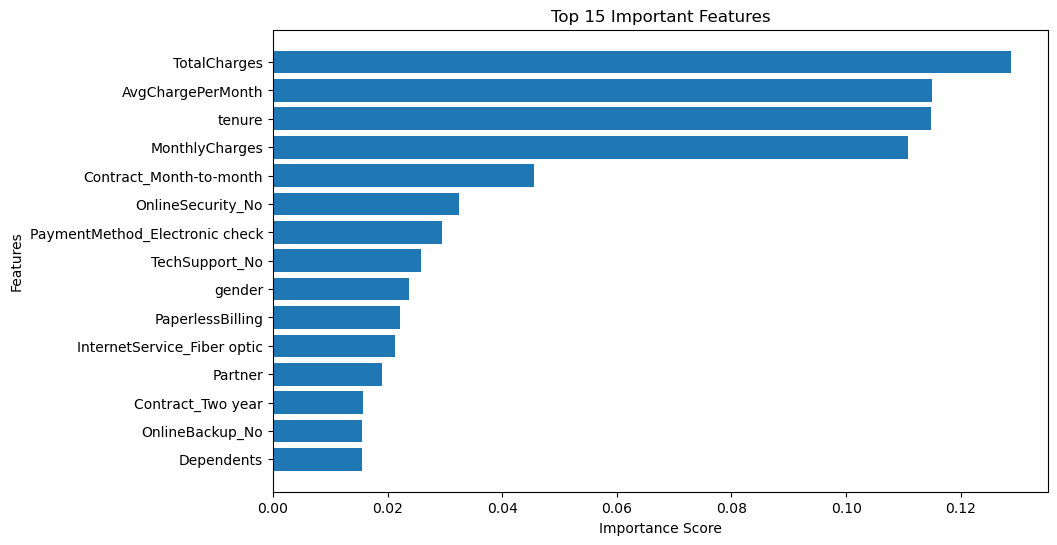

In [37]:
import matplotlib.pyplot as plt

top_features = importance_df.head(15)

plt.figure(figsize=(10,6))

plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.gca().invert_yaxis()

plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Top 15 Important Features")

plt.show()

In [35]:
X_train.shape

(5634, 47)

In [38]:
top_features = importance_df['Feature'].head(15).tolist()

In [39]:
top_features.append('Churn')

In [40]:
final_df = df[top_features]

In [41]:
final_df.to_csv("processed_data.csv", index=False)